Model performance (test set):
Seasonal Naive RMSE: 3198710.35
ETS RMSE:            5516043.00


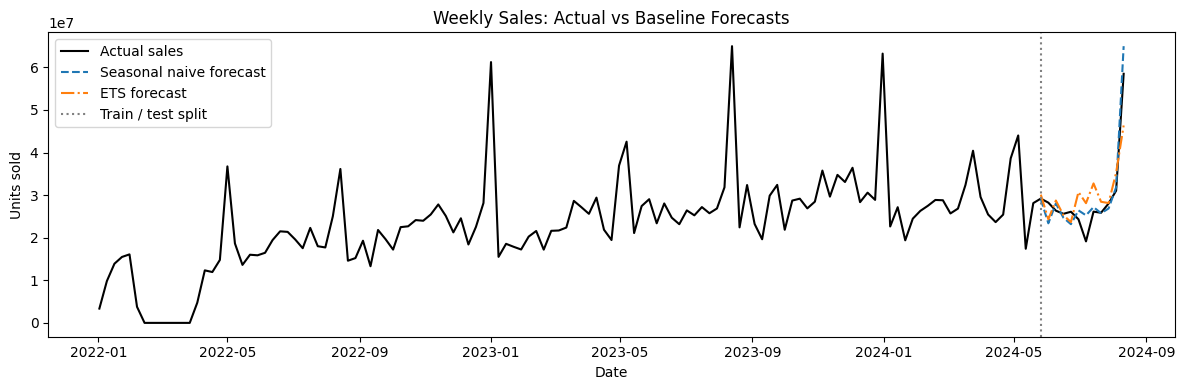

In [9]:
# ======================================
# Demand Forecasting: Baseline Models
# Seasonal Naive vs ETS
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

# --------------------------------------
# 1. Load and prepare data
# --------------------------------------

# Load cleaned data
df = pd.read_excel("Sample_data_cleaned.xlsx")

# Ensure datetime
df["date"] = pd.to_datetime(df["date"])

# --------------------------------------
# 2. Aggregate daily data to weekly
# --------------------------------------

# Weekly aggregation aligns with HQ planning horizon
df_weekly = (
    df
    .set_index("date")
    .resample("W")["sales"]
    .sum()
    .reset_index()
)

# --------------------------------------
# 3. Train–test split (time-based)
# --------------------------------------

test_horizon = 12  # last 12 weeks as test set

train = df_weekly.iloc[:-test_horizon]
test  = df_weekly.iloc[-test_horizon:]

y_train = train["sales"].values
y_test  = test["sales"].values

dates_train = train["date"]
dates_test  = test["date"]

# --------------------------------------
# 4. Seasonal Naive Model
# --------------------------------------

# Weekly data with yearly seasonality
season_length = 52

# Seasonal naive forecast:
# y_hat(t+h) = y(t+h-52)
y_naive_forecast = y_train[-season_length:][:test_horizon]

# --------------------------------------
# 5. ETS Model (Additive Seasonality)
# --------------------------------------

ets_model = ExponentialSmoothing(
    y_train,
    trend=None,
    seasonal="add",
    seasonal_periods=season_length
)

ets_fit = ets_model.fit(optimized=True)

y_ets_forecast = ets_fit.forecast(test_horizon)

# --------------------------------------
# 6. RMSE Evaluation
# --------------------------------------

rmse_naive = np.sqrt(mean_squared_error(y_test, y_naive_forecast))
rmse_ets   = np.sqrt(mean_squared_error(y_test, y_ets_forecast))


print("Model performance (test set):")
print(f"Seasonal Naive RMSE: {rmse_naive:.2f}")
print(f"ETS RMSE:            {rmse_ets:.2f}")

# --------------------------------------
# 7. Visualization: Actual vs Forecasts
# --------------------------------------

plt.figure(figsize=(12, 4))

# Actual data
plt.plot(
    df_weekly["date"],
    df_weekly["sales"],
    label="Actual sales",
    color="black"
)

# Seasonal naive forecast
plt.plot(
    dates_test,
    y_naive_forecast,
    linestyle="--",
    label="Seasonal naive forecast"
)

# ETS forecast
plt.plot(
    dates_test,
    y_ets_forecast,
    linestyle="-.",
    label="ETS forecast"
)

# Train-test split marker
plt.axvline(
    dates_test.iloc[0],
    color="gray",
    linestyle=":",
    label="Train / test split"
)

plt.title("Weekly Sales: Actual vs Baseline Forecasts")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.legend()
plt.tight_layout()
plt.show()